In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [44]:
#load delta t data from file
path_delta_t = '/raid1/genli/Data_D2O/run19520_19529_dt0-20000_sa0-100000/Total/Total_run_19520_19529_delta_t_histogram.pkl'

#load delta t data histogram from file
delta_t = np.load(path_delta_t, allow_pickle=True)
#print attributes of delta_t
print(delta_t.keys())
#extract data from delta_t
hist_delta_t = delta_t['hist']
centers_delta_t = delta_t['bin_centers']   
err_delta_t = delta_t['errorbars']

dict_keys(['hist', 'bin_centers', 'errorbars'])


Fit 1: tau = 2111.87 +/- 92.42 ns


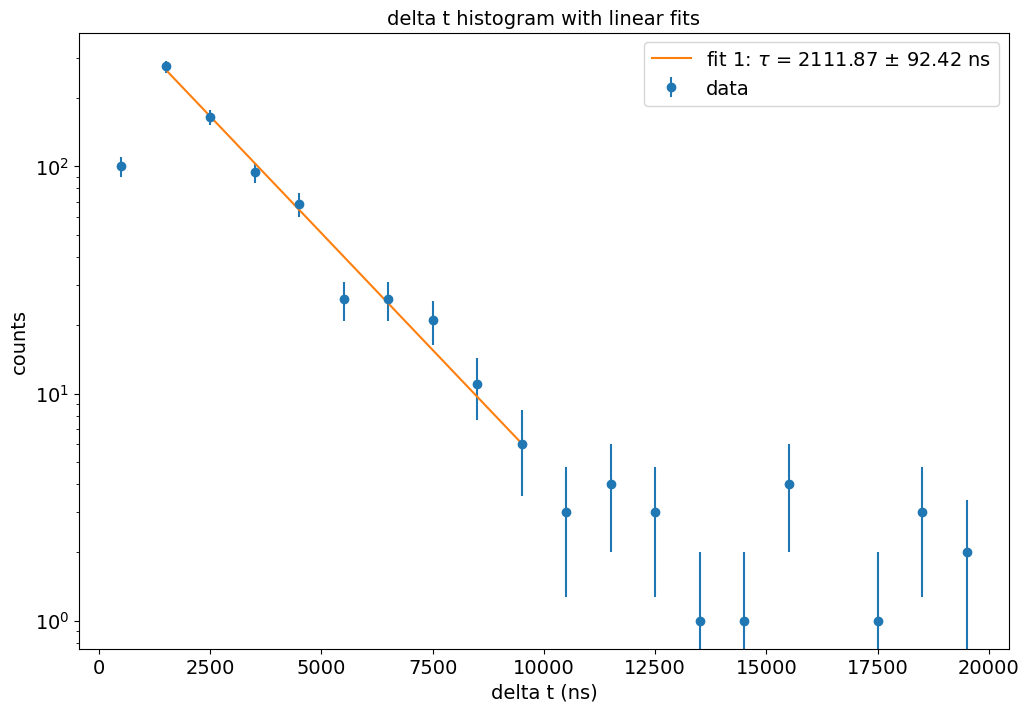

In [45]:
# Fit the log of the histogram with linear function, y = a + b*x, and \tau = 1/b
def linear(x, a, b):
    return a + b*x

# Fit the log of the histogram
# Define three regions for fitting
region_1 = (centers_delta_t > 1000) & (centers_delta_t < 10000)

# Plot the histogram again
plt.figure(figsize=(12, 8))
plt.errorbar(centers_delta_t, hist_delta_t, yerr=err_delta_t, fmt='o', label='data')
plt.yscale('log')
plt.xlabel('delta t (ns)', fontsize=14)
plt.ylabel('counts', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('delta t histogram with linear fits', fontsize=14)
plt.legend(fontsize=14)


# Fit and plot the linear fits for each region
popt, pcov = curve_fit(linear, centers_delta_t[region_1], np.log(hist_delta_t[region_1]), sigma=err_delta_t[region_1]/hist_delta_t[region_1], absolute_sigma=True)
err_tau = 1/popt[1]**2 * np.sqrt(np.diag(pcov))[1]
print('Fit 1: tau = {:.2f} +/- {:.2f} ns'.format(-1/popt[1], err_tau))
plt.plot(centers_delta_t[region_1], np.exp(linear(centers_delta_t[region_1], *popt)), label='fit 1: $\\tau$ = {:.2f} $\\pm$ {:.2f} ns'.format(-1/popt[1], err_tau))
plt.legend(fontsize=14)
plt.show()

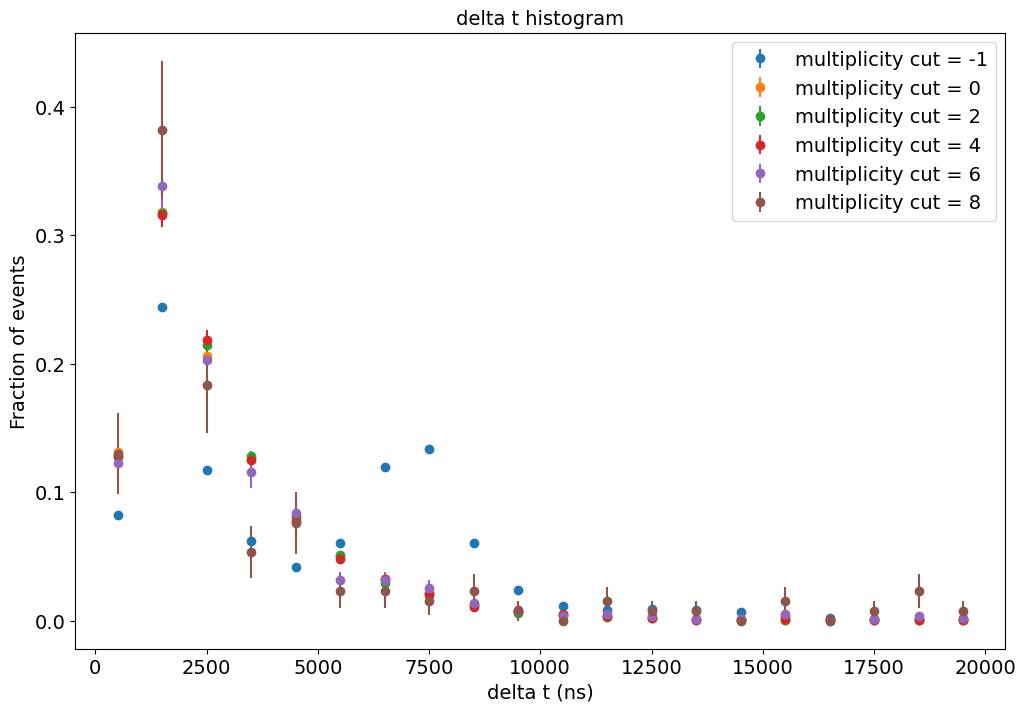

In [53]:
# Define paths and mcut values
mcut_values = [-1, 0, 2, 4, 6, 8, 10]
paths = [f"/raid1/genli/Data_D2O/run19520_19529_dt0-20000_sa0-100000_mcut{mcut}/Total/Total_run_19520_19529_delta_t_histogram.pkl" for mcut in mcut_values]

# Initialize dictionaries to store data
hist_data = {}
centers_data = {}
err_data = {}
hist_data_n = {}
err_data_n = {}

# Load data and extract histograms, centers, and errorbars
for mcut, path in zip(mcut_values, paths):
    delta_t_data = np.load(path, allow_pickle=True)
    hist_data[mcut] = delta_t_data['hist']
    centers_data[mcut] = delta_t_data['bin_centers']
    err_data[mcut] = delta_t_data['errorbars']
    
    # Renormalize the histogram data and errorbars
    hist_data_n[mcut] = hist_data[mcut] / np.sum(hist_data[mcut])
    err_data_n[mcut] = err_data[mcut] / np.sum(hist_data[mcut])

# Plot the histograms with errorbars
plt.figure(figsize=(12, 8))
for mcut in mcut_values[:-1]:  # Exclude mcut 10 for plotting
    plt.errorbar(centers_data[mcut], hist_data_n[mcut], yerr=err_data_n[mcut], fmt='o', label=f'multiplicity cut = {mcut}')
# plt.yscale('log')
plt.xlabel('delta t (ns)', fontsize=14)
plt.ylabel('Fraction of events', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('delta t histogram', fontsize=14)
plt.legend(fontsize=14)

Fit 0: tau = 2170.84 +/- 16.15 ns
Fit 2: tau = 2131.53 +/- 25.44 ns
Fit 4: tau = 2136.14 +/- 45.61 ns
Fit 6: tau = 2111.87 +/- 92.42 ns
Fit 8: tau = 1953.39 +/- 198.79 ns


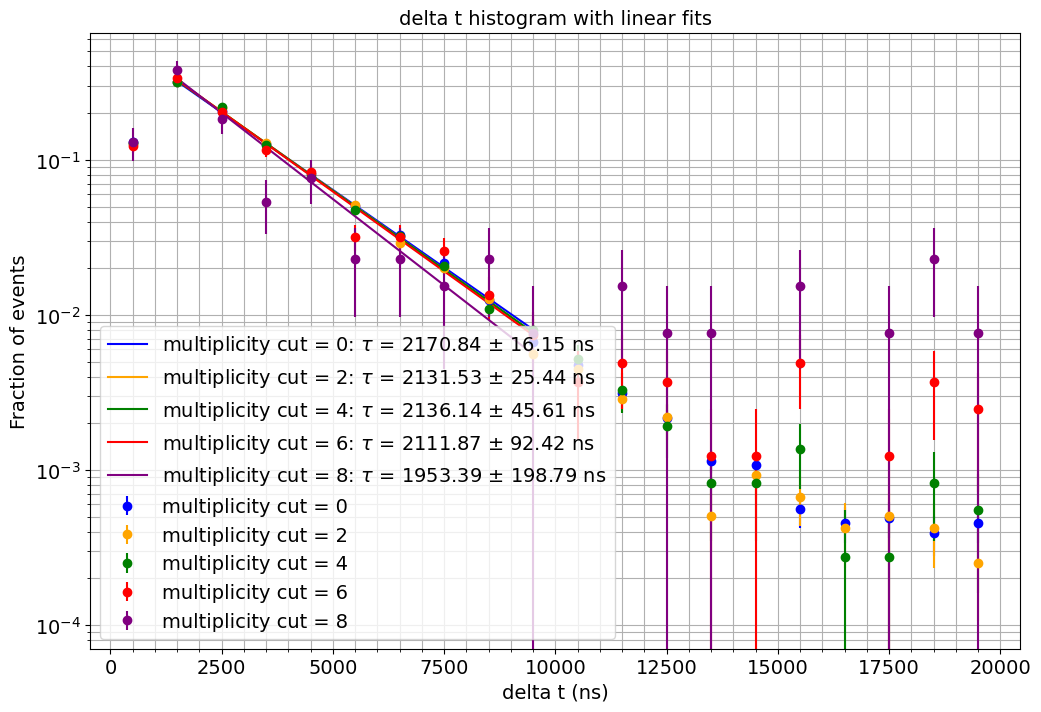

<Figure size 640x480 with 0 Axes>

In [51]:
#fit the log of the histogram with linear function, y = a + b*x, and \tau = 1/b
# Fit the log of the histogram
# Define the region for fitting
region = (centers_delta_t > 1000) & (centers_delta_t < 10000)

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']

plt.figure(figsize=(12, 8))
count = 0
for mcut in mcut_values[1:-1]:  # Exclude mcut 10 for fitting
    # Fit the log of the histogram
    popt, pcov = curve_fit(linear, centers_data[mcut][region], np.log(hist_data_n[mcut][region]), sigma=err_data[mcut][region]/hist_data[mcut][region], absolute_sigma=True)
    err_tau = 1/popt[1]**2 * np.sqrt(np.diag(pcov))[1]
    print(f'Fit {mcut}: tau = {-1/popt[1]:.2f} +/- {err_tau:.2f} ns')
    plt.plot(centers_data[mcut][region], np.exp(linear(centers_data[mcut][region], *popt)), label=f'multiplicity cut = {mcut}: $\\tau$ = {-1/popt[1]:.2f} $\\pm$ {err_tau:.2f} ns', color=colors[count])
    
    
    plt.errorbar(centers_data[mcut], hist_data_n[mcut], yerr=err_data_n[mcut], fmt='o', label=f'multiplicity cut = {mcut}', color=colors[count])
    count += 1
plt.yscale('log')
plt.xlabel('delta t (ns)', fontsize=14)
plt.ylabel('Fraction of events', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('delta t histogram with linear fits', fontsize=14)
plt.legend(fontsize=14)
#enable grid and minor ticks
plt.grid(True, which='both')
plt.minorticks_on()
#show the plot
plt.show()

#save the figure
plt.savefig('delta_t_histogram_mcut.png')

